In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import scipy.stats as stats
from scipy.stats import spearmanr, hypergeom

from statsmodels.stats.multitest import multipletests

# GO enrichment
import gseapy as gp

## CellOracle
import celloracle as co
from celloracle.applications import Gradient_calculator, Oracle_development_module

## Load data

In [2]:
## DATA (CellOracle object before fitting GRN)
oracle = co.load_hdf5("../data/celloracle_data/celloracle_unfit.celloracle.oracle")

# Load object
links = co.load_hdf5("../data/celloracle_data/celloracle_links_raw.celloracle.links")

Inspect loaded objects:

In [3]:
oracle

Oracle object

Meta data
    celloracle version used for instantiation: 0.20.0
    n_cells: 1604
    n_genes: 2100
    cluster_name: leiden_annotated
    dimensional_reduction_name: X_umap
    n_target_genes_in_TFdict: 1941 genes
    n_regulatory_in_TFdict: 809 genes
    n_regulatory_in_both_TFdict_and_scRNA-seq: 809 genes
    n_target_genes_both_TFdict_and_scRNA-seq: 1941 genes
    k_for_knn_imputation: 40
Status
    Gene expression matrix: Ready
    BaseGRN: Ready
    PCA calculation: Done
    Knn imputation: Done
    GRN calculation for simulation: Not finished

In [4]:
links

## FIT GRN — RIDGE REGRESSION PER CLUSTER

Use Links object to store raw GRNs per cluster (with weights and associated p-values):

In [5]:
"""
# Infer GRN per cluster with Ridge Regression
# alpha: regularization strength. Higher = sparser network.
# verbose_level=10 prints progress per cluster
links = oracle.get_links(
    cluster_name_for_GRN_unit='leiden_annotated',
    alpha=10,
    verbose_level=10
)

# Save Links object
links.to_hdf5(file_path="../data/celloracle_data/celloracle_links_raw.celloracle.links")
"""

'\n# Infer GRN per cluster with Ridge Regression\n# alpha: regularization strength. Higher = sparser network.\n# verbose_level=10 prints progress per cluster\nlinks = oracle.get_links(\n    cluster_name_for_GRN_unit=\'leiden_annotated\',\n    alpha=10,\n    verbose_level=10\n)\n\n# Save Links object\nlinks.to_hdf5(file_path="../data/celloracle_data/celloracle_links_raw.celloracle.links")\n'

Inspect the Links object:

In [6]:
links.links_dict.keys()

dict_keys(['ASO_KO', 'Ectoderm_1', 'Ectoderm_2', 'Mesoderm_1', 'Mesoderm_2', 'mESCs'])

In [7]:
links.links_dict["ASO_KO"]

,source,target,coef_mean,coef_abs,p,-logp
0,E2f2,1110051M20Rik,-0.004956,0.004956,1.581332e-01,0.800977
1,Klf16,1110051M20Rik,0.085048,0.085048,6.993005e-07,6.155336
2,Nfe2,1110051M20Rik,-0.010746,0.010746,3.024051e-03,2.519411
3,Klf1,1110051M20Rik,0.002166,0.002166,1.519522e-01,0.818293
4,Crebzf,1110051M20Rik,-0.014760,0.014760,1.886380e-03,2.724371
...,...,...,...,...,...,...
719588,Rarb,Zzef1,0.021106,0.021106,4.898473e-10,9.309939
719589,Tfap2a,Zzef1,0.011528,0.011528,1.918989e-07,6.716927
719590,Vdr,Zzef1,-0.005756,0.005756,9.833774e-04,3.007280
719591,Elf2,Zzef1,-0.003766,0.003766,3.479081e-02,1.458535


## Plots to decide filtering


In [8]:
## Auxiliary plot functions + shared conventions
## ------------------------------------------------

# Canonical color/label convention for edge sign, reused everywhere
SIGN_COLORS = {'positive': '#2ca02c', 'negative': '#d62728'} 
SIGN_ORDER = ['positive', 'negative']


def get_shared_ylim(*dataframes, col='Edges', floor=0, pad_factor=1.15):
    """
    Compute ONE y-limit shared across several DataFrames, so figures meant
    to be compared (Total vs Positive vs Negative) use the SAME scale
    instead of each auto-scaling independently. Without this, matplotlib
    stretches each figure to fill its own frame, making very different
    magnitudes look deceptively similar.
    """
    all_vals = pd.concat([df[col] for df in dataframes if len(df) > 0])
    vmax = all_vals.max() if len(all_vals) > 0 else 1
    return (floor, vmax * pad_factor if vmax > 0 else 1)


def plot_dual_boxplot(ax, data, x_col, title, x_label):
    # Color palette: blue (inward), red (outward) -- encodes DIRECTION, not sign
    my_pal = {'Inward': '#1f77b4', 'Outward': '#d62728'}

    sns.boxplot(
        data=data, x=x_col, y='Edges', hue='Direction',
        palette=my_pal, showfliers=False, dodge=True, ax=ax, boxprops=dict(alpha=0.5)
    )
    sns.stripplot(
        data=data, x=x_col, y='Edges', hue='Direction',
        palette=my_pal, dodge=True, jitter=0.2, alpha=0.7, size=5, ax=ax, edgecolor='black', linewidth=0.5
    )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Number of Edges", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title="Edge Direction")


def plot_cluster_dynamics(ax, data, title, x_label, ylim=None, scale='linear'):
    sns.boxplot(
        data=data, x='Threshold', y='Edges',
        color='lightgray', showfliers=False, ax=ax, boxprops=dict(alpha=0.5)
    )
    sns.stripplot(
        data=data, x='Threshold', y='Edges', hue='Cluster',
        palette='tab10', dodge=False, jitter=0.15, alpha=0.9, size=7,
        ax=ax, edgecolor='black', linewidth=0.5
    )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Number of Edges", fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # CHANGED: linear by default. At these small per-lncRNA counts (single/
    # low double digits), log scale compresses real differences AND hides
    # zero-count categories entirely (log(0) is undefined). Pass scale='log'
    # to restore the old behaviour.
    if scale == 'log':
        ax.set_yscale('log')
        ax.set_ylim(ylim if ylim is not None else (1, None))
        if ylim is None:
            ax.set_ylim(bottom=1)
    else:
        ax.set_ylim(ylim if ylim is not None else (0, None))

    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Cluster", fontsize=9)

General

In [9]:
# We iterate over the UNFILTERED raw results (links_dict) to see everything
clusters = list(links.links_dict.keys())

n_clusters = len(clusters)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

p_thresholds = [1e-2, 1e-4, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10]
coef_thresholds = [0.001, 0.005, 0.010, 0.015, 0.025, 0.040, 0.050]

# General table
def build_master_edges(links_dict):
    frames = []
    for cluster, df in links_dict.items():
        if df is None or len(df) == 0:
            continue
        d = df.copy()
        d['cluster'] = cluster
        frames.append(d)
    master = pd.concat(frames, ignore_index=True)

    master['sign'] = np.select(
        [master['coef_mean'] > 0, master['coef_mean'] < 0],
        ['positive', 'negative'],
        default='zero'
    )

    # Reuse CellOracle's own -log10(p) column
    # with a possibly different clipping convention in each cell.
    master['neg_log10_p'] = master['-logp'] if '-logp' in master.columns else -np.log10(master['p'].clip(lower=1e-300))

    return master

master_edges = build_master_edges(links.links_dict)
print(f"master_edges: {len(master_edges):,} edges across {master_edges['cluster'].nunique()} clusters")
print(master_edges['sign'].value_counts())

master_edges: 4,317,558 edges across 6 clusters
positive    2167138
negative    2121162
zero          29258
Name: sign, dtype: int64


Check how the regression affect the number of edges and coefficient values for different p-values:

In [10]:
# =====================================================================
# EVALUATION OF NETWORK SIZE VS P-VALUE THRESHOLD
# =====================================================================
edge_counts = []

for p_val in p_thresholds:
    links.filter_links(p=p_val, threshold_number=None)
    for cluster, df_filtered in links.filtered_links.items():
        count = len(df_filtered) if df_filtered is not None else 0
        edge_counts.append({'P_value': p_val, '-Log10(P)': -np.log10(p_val), 'Cluster': cluster, 'Edges': count})

df_edges = pd.DataFrame(edge_counts)

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_edges, x='-Log10(P)', y='Edges', color='lightblue', showfliers=False, ax=ax1)
sns.swarmplot(data=df_edges, x='-Log10(P)', y='Edges', hue='Cluster', palette='Set2', size=6, ax=ax1)

ax1.set_title("Evolution of GRN total edges vs p-val threshold", fontsize=14, fontweight='bold')
ax1.set_xlabel("-log10 threshold", fontsize=12, fontweight='bold')
ax1.set_ylabel("GRN total edges", fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.set_yscale('log')
ax1.set_ylim(bottom=1e3) # Visualization 

plt.tight_layout()
fig1.savefig("../Plots/GRN_construction/GRN_edges_vs_pval.png", bbox_inches='tight')

# =====================================================================
# SCATTER PLOTS: COEF ABS VS P-VALUE (VOLCANO STYLE)
# =====================================================================
fig2, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten() if n_clusters > 1 else [axes]

for i, cluster in enumerate(clusters):
    ax = axes[i]
    df_cl = master_edges[master_edges['cluster'] == cluster]

    if len(df_cl) == 0:
        ax.set_title(f"{cluster} (Empty)")
        continue

    point_colors = df_cl['sign'].map(SIGN_COLORS).fillna('gray')
    ax.scatter(df_cl['neg_log10_p'], df_cl['coef_abs'], c=point_colors, alpha=0.1, s=3)

    ax.set_title(f"Cluster:{cluster}", fontsize=12, fontweight='bold')
    ax.set_xlabel("-log10(p-val)")
    ax.set_ylabel("$|\\beta|$ threshold")
    ax.grid(True, linestyle='--', alpha=0.3)

    pval_line = ax.axvline(8, color='black', linestyle='--', alpha=0.5, label='p=1e-8')
    # FIX: the scatter colors had no legend entry anywhere in the original cell.
    legend_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='', color=SIGN_COLORS['positive'], label='coef_mean > 0'),
        plt.Line2D([0], [0], marker='o', linestyle='', color=SIGN_COLORS['negative'], label='coef_mean < 0'),
        pval_line
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
fig2.savefig("../Plots/GRN_construction/GRN_coef_vs_pval.png", bbox_inches='tight', dpi=300)

2026-08-26 13:30:39,740 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:30:39,743 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:30:39,763 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:30:39,766 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


In [11]:
def plot_lncrna_scatter(master_edges, lncrna_label, lncrna_id, direction):
    
    # 1. Filter the master dataframe for the specific lncRNA and direction
    if direction == 'Inward':
        # TFs hitting the lncRNA
        df_filtered = master_edges[master_edges['target'] == lncrna_id].copy()
    elif direction == 'Outward':
        # lncRNA hitting the Targets
        df_filtered = master_edges[master_edges['source'] == lncrna_id].copy()
    else:
        raise ValueError("Direction must be 'Inward' or 'Outward'")

    # 2. Setup the Grid
    clusters = list(master_edges['cluster'].unique())
    n_clusters = len(clusters)
    n_cols = 3
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
    
    # Add a main title for the whole figure
    fig.suptitle(f"{lncrna_label} {direction.upper()} Edges: $|\\beta|$ vs -log10(p-val)", fontsize=18, fontweight='bold', y=1.02)
    
    axes = axes.flatten() if n_clusters > 1 else [axes]

    # 3. Iterate through clusters and plot
    for i, cluster in enumerate(clusters):
        ax = axes[i]
        df_cl = df_filtered[df_filtered['cluster'] == cluster]

        # If the lncRNA has no edges in this cluster, leave it empty
        if len(df_cl) == 0:
            ax.set_title(f"Cluster: {cluster} (Empty)", fontsize=12, fontweight='bold', color='gray')
            ax.axis('off') # Hide axes for completely empty plots to reduce visual clutter
            continue

        # Map colors based on sign
        point_colors = df_cl['sign'].map(SIGN_COLORS).fillna('gray')
        
        # Plot Scatter (increased size and alpha for visibility of single genes)
        ax.scatter(df_cl['neg_log10_p'], df_cl['coef_abs'], c=point_colors, alpha=0.6, s=15, edgecolor='none')

        # Aesthetics (keeping your exact style)
        ax.set_title(f"Cluster: {cluster}", fontsize=12, fontweight='bold')
        ax.set_xlabel("-log10(p-val)")
        ax.set_ylabel("$|\\beta|$ threshold")
        ax.grid(True, linestyle='--', alpha=0.3)

        # Reference line and Custom Legend
        pval_line = ax.axvline(8, color='black', linestyle='--', alpha=0.5, label='p=1e-8')
        
        legend_handles = [
            plt.Line2D([0], [0], marker='o', linestyle='', color=SIGN_COLORS.get('Positive', 'green'), label='coef_mean > 0'),
            plt.Line2D([0], [0], marker='o', linestyle='', color=SIGN_COLORS.get('Negative', 'red'), label='coef_mean < 0'),
            pval_line
        ]
        ax.legend(handles=legend_handles, loc='upper left', fontsize=7)

    # Hide any unused subplots in the grid
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    
    # Save the figure safely
    filename = f"../Plots/GRN_construction/GRN_scatter_{lncrna_label}_{direction}.png"
    fig.savefig(filename, bbox_inches='tight', dpi=300)


# =====================================================================
# EXECUTE THE 4 PLOTS
# =====================================================================

# You can adjust these IDs if they differ in your master_edges dataframe
lncrnas = {
    'C13': 'C130026L21Rik',
    'RMST1': 'Rmst'
}

for label, gene_id in lncrnas.items():
    plot_lncrna_scatter(master_edges, lncrna_label=label, lncrna_id=gene_id, direction='Inward')
    plot_lncrna_scatter(master_edges, lncrna_label=label, lncrna_id=gene_id, direction='Outward')

We will check negative and positive edge distribution with p_value to confirm that POSITIVE EDGES HAVE HIGHER Pval

In [12]:
# =====================================================================
# OVERLAPPED HISTOGRAMS: POSITIVE VS NEGATIVE EDGES
# =====================================================================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
fig.suptitle("Distribution of Edges vs -log10(p-value) (Positive vs Negative)", fontsize=18, fontweight='bold')
axes = axes.flatten() if n_clusters > 1 else [axes]

for i, cluster in enumerate(clusters):
    ax = axes[i]
    df_cl = master_edges[master_edges['cluster'] == cluster]

    if len(df_cl) == 0:
        ax.set_title(f"Cluster: {cluster} (Empty)", fontsize=12, fontweight='bold')
        continue

    for sign_name in SIGN_ORDER:
        df_sign = df_cl[df_cl['sign'] == sign_name]
        if len(df_sign) == 0:
            continue
        symbol = '>' if sign_name == 'positive' else '<'
        sns.histplot(
            x=df_sign['neg_log10_p'], bins=50, color=SIGN_COLORS[sign_name], ax=ax,
            kde=True, element='step', alpha=0.3, label=f"{sign_name.capitalize()} ($\\beta {symbol} 0$)"
        )

    ax.set_title(f"Cluster: {cluster}", fontsize=12, fontweight='bold')
    ax.set_xlabel("-log10(p-val)")
    ax.set_ylabel("Edge Count")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.axvline(8, color='black', linestyle='--', alpha=0.5, label='p=1e-8')
    ax.legend(loc='upper right', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
fig.savefig("../Plots/GRN_construction/GRN_edge_sign_vs_pval_hist.png", bbox_inches='tight', dpi=300)

Filter by absolute threshold and evaluate the effect on the number of edges:

In [13]:
# =====================================================
# EVALUATION OF NETWORK SIZE VS COEFFICIENT THRESHOLD
# =====================================================

edge_counts_coef = []

# We keep a basic statistical safeguard (p < 0.01) to remove pure noise,
# but the main driving filter will be your physical coefficient threshold.
BASE_P_VAL = 0.01

for coef_th in coef_thresholds:
    for cluster, df_raw in links.links_dict.items():
        if df_raw is None or len(df_raw) == 0:
            count = 0
        else:
            # Apply your physical logic: |beta| >= threshold AND p < 0.01
            mask = (df_raw['coef_abs'] >= coef_th) & (df_raw['p'] < BASE_P_VAL)
            count = mask.sum()
            
        edge_counts_coef.append({
            'Coef_Threshold': coef_th,
            'Cluster': cluster,
            'Edges': count
        })

df_edges_coef = pd.DataFrame(edge_counts_coef)

# =====================================================================
# 2. PLOTTING THE THRESHOLD DYNAMICS (BOXPLOT)
# =====================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot shows the median network size drop across all clusters
sns.boxplot(
    data=df_edges_coef, 
    x='Coef_Threshold', 
    y='Edges', 
    color='lightgreen', 
    showfliers=False, 
    ax=ax
)

# Swarmplot overlays the individual clusters to see the physical asymmetry
sns.swarmplot(
    data=df_edges_coef, 
    x='Coef_Threshold', 
    y='Edges', 
    hue='Cluster', 
    palette='Set2', 
    size=6, 
    ax=ax
)

ax.set_title("Evolution of network total # of edges with $|\\beta|$ threshold", fontsize=14, fontweight='bold')
ax.set_xlabel("$|\\beta|$ threshold", fontsize=12, fontweight='bold')
ax.set_ylabel("GRN total edges", fontsize=12, fontweight='bold')

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

ax.set_yscale('log')
ax.set_ylim(bottom=1e3) # Visualization 

plt.tight_layout()
fig.savefig("../Plots/GRN_construction/GRN_edges_vs_coeff.png", bbox_inches='tight')

2026-08-26 13:31:29,251 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:29,253 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:29,272 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:29,275 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Check the evolution of inward and outward edges to the lncRNAs with the pvalue and abs_coefficient:

In [14]:
# =====================================================================
# PARAMETER SWEEP FOR LncRNAs (P-Value & Coefficient)
# =====================================================================
lncrnas = {'C13': 'C130026L21Rik', 'RMST1': 'Rmst'}
p_thresholds = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
coef_thresholds = [0.001, 0.005, 0.010, 0.015, 0.025, 0.040, 0.050]
BASE_P_VAL = 0.01

records_p = []
records_coef = []

for cluster, df_raw in master_edges.groupby('cluster'):

    # --- A. p-value sweep ---
    for p_val in p_thresholds:
        df_filt = df_raw[df_raw['p'] < p_val]
        for name, gen_id in lncrnas.items():
            for sign_name in SIGN_ORDER:
                df_sign = df_filt[df_filt['sign'] == sign_name]
                inward = (df_sign['target'] == gen_id).sum()
                outward = (df_sign['source'] == gen_id).sum()
                records_p.append({'Threshold': -np.log10(p_val), 'LncRNA': name, 'Direction': 'Inward', 'Sign': sign_name, 'Edges': inward, 'Cluster': cluster})
                records_p.append({'Threshold': -np.log10(p_val), 'LncRNA': name, 'Direction': 'Outward', 'Sign': sign_name, 'Edges': outward, 'Cluster': cluster})

    # --- B. |beta| sweep (with a fixed p < 0.01 sanity filter) ---
    for coef_th in coef_thresholds:
        df_filt = df_raw[(df_raw['coef_abs'] >= coef_th) & (df_raw['p'] < BASE_P_VAL)]
        for name, gen_id in lncrnas.items():
            for sign_name in SIGN_ORDER:
                df_sign = df_filt[df_filt['sign'] == sign_name]
                inward = (df_sign['target'] == gen_id).sum()
                outward = (df_sign['source'] == gen_id).sum()
                records_coef.append({'Threshold': coef_th, 'LncRNA': name, 'Direction': 'Inward', 'Sign': sign_name, 'Edges': inward, 'Cluster': cluster})
                records_coef.append({'Threshold': coef_th, 'LncRNA': name, 'Direction': 'Outward', 'Sign': sign_name, 'Edges': outward, 'Cluster': cluster})

df_p = pd.DataFrame(records_p)
df_coef = pd.DataFrame(records_coef)

df_p_total = df_p.groupby(['Threshold', 'LncRNA', 'Direction', 'Cluster'], as_index=False)['Edges'].sum()
df_coef_total = df_coef.groupby(['Threshold', 'LncRNA', 'Direction', 'Cluster'], as_index=False)['Edges'].sum()

# ===============================
# DUAL-BOXPLOTS: Inward vs Outward totals
# ===============================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True, sharey=True)
plot_dual_boxplot(axes[0, 0], df_p_total[df_p_total['LncRNA'] == 'C13'], 'Threshold', "C13", "-Log10(P-value)")
plot_dual_boxplot(axes[0, 1], df_p_total[df_p_total['LncRNA'] == 'RMST1'], 'Threshold', "RMST1", "-log10(p-value)")
plot_dual_boxplot(axes[1, 0], df_coef_total[df_coef_total['LncRNA'] == 'C13'], 'Threshold', "C13", "$|\\beta|$ threshold")
plot_dual_boxplot(axes[1, 1], df_coef_total[df_coef_total['LncRNA'] == 'RMST1'], 'Threshold', "RMST1", "$|\\beta|$ threshold")

fig.savefig("../Plots/GRN_construction/lncRNA_regulation_vs_thresholds.png", bbox_inches='tight')

2026-08-26 13:31:33,561 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:33,564 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:33,589 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:33,591 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:33,615 - INFO - Using categorical units to plot a list of strings that are all parsable as 

Same as before but looking at cluster distribution:

=> ylim_p / ylim_coef defined for next cell, so we can use the same scale for Positive vs Negative comparisons

In [15]:
# ===============================
# TOTAL (both signs) -- P-VALUE SWEEP
# ===============================
# Shared y-limit: computed from df_p_total so this "Total" figure and the
# Positive/Negative figures in the next cell use the SAME scale.
ylim_p = get_shared_ylim(df_p_total)

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True, sharex=True, sharey=True)
fig1.suptitle("lncRNA network edges vs p-value threshold (by cluster)", fontsize=18, fontweight='bold')
plot_cluster_dynamics(axes1[0, 0], df_p_total[(df_p_total['LncRNA']=='C13') & (df_p_total['Direction']=='Inward')], "C13 INWARD", "-log10(p-value)", ylim=ylim_p)
plot_cluster_dynamics(axes1[0, 1], df_p_total[(df_p_total['LncRNA']=='RMST1') & (df_p_total['Direction']=='Inward')], "RMST1 INWARD", "-log10(p-value)", ylim=ylim_p)
plot_cluster_dynamics(axes1[1, 0], df_p_total[(df_p_total['LncRNA']=='C13') & (df_p_total['Direction']=='Outward')], "C13 OUTWARD", "-log10(p-value)", ylim=ylim_p)
plot_cluster_dynamics(axes1[1, 1], df_p_total[(df_p_total['LncRNA']=='RMST1') & (df_p_total['Direction']=='Outward')], "RMST1 OUTWARD", "-log10(p-value)", ylim=ylim_p)
fig1.savefig("../Plots/GRN_construction/lncRNA_edges_vs_pval_by_cluster.png", bbox_inches='tight')

# ===============================
# TOTAL (both signs) -- |beta| SWEEP
# ===============================
ylim_coef = get_shared_ylim(df_coef_total)

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True, sharex=True, sharey=True)
fig2.suptitle("lncRNA network edges vs $|\\beta|$ threshold (by cluster)", fontsize=18, fontweight='bold')
plot_cluster_dynamics(axes2[0, 0], df_coef_total[(df_coef_total['LncRNA']=='C13') & (df_coef_total['Direction']=='Inward')], "C13 INWARD", "$|\\beta|$ threshold", ylim=ylim_coef)
plot_cluster_dynamics(axes2[0, 1], df_coef_total[(df_coef_total['LncRNA']=='RMST1') & (df_coef_total['Direction']=='Inward')], "RMST1 INWARD", "$|\\beta|$ threshold", ylim=ylim_coef)
plot_cluster_dynamics(axes2[1, 0], df_coef_total[(df_coef_total['LncRNA']=='C13') & (df_coef_total['Direction']=='Outward')], "C13 OUTWARD", "$|\\beta|$ threshold", ylim=ylim_coef)
plot_cluster_dynamics(axes2[1, 1], df_coef_total[(df_coef_total['LncRNA']=='RMST1') & (df_coef_total['Direction']=='Outward')], "RMST1 OUTWARD", "$|\\beta|$ threshold", ylim=ylim_coef)
fig2.savefig("../Plots/GRN_construction/lncRNA_edges_vs_coef_by_cluster.png", bbox_inches='tight')

2026-08-26 13:31:34,399 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:34,402 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:34,422 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:34,424 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:34,442 - INFO - Using categorical units to plot a list of strings that are all parsable as 

We are going to look specifically to the sign of the regulatory edges in the lncRNAs, i.e. same figure as before but with two figures per case:

In [16]:
# =======================================================
# POSITIVE vs NEGATIVE split, on the SAME scale as the "Total" figures above
# =======================================================
def plot_sign_split(df, sign_name, metric_label, x_label, ylim, save_prefix="lncRNA"):
    df_sign = df[df['Sign'] == sign_name]
    label = sign_name.capitalize()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True, sharex=True, sharey=True)
    fig.suptitle(f"lncRNA network {label.upper()} edges vs {metric_label} threshold (by cluster)", fontsize=18, fontweight='bold')

    plot_cluster_dynamics(axes[0, 0], df_sign[(df_sign['LncRNA']=='C13') & (df_sign['Direction']=='Inward')], f"C13 INWARD ({label})", x_label, ylim=ylim)
    plot_cluster_dynamics(axes[0, 1], df_sign[(df_sign['LncRNA']=='RMST1') & (df_sign['Direction']=='Inward')], f"RMST1 INWARD ({label})", x_label, ylim=ylim)
    plot_cluster_dynamics(axes[1, 0], df_sign[(df_sign['LncRNA']=='C13') & (df_sign['Direction']=='Outward')], f"C13 OUTWARD ({label})", x_label, ylim=ylim)
    plot_cluster_dynamics(axes[1, 1], df_sign[(df_sign['LncRNA']=='RMST1') & (df_sign['Direction']=='Outward')], f"RMST1 OUTWARD ({label})", x_label, ylim=ylim)

    fname = f"../Plots/GRN_construction/{save_prefix}_{sign_name.upper()}_edges_vs_{'pval' if 'p-value' in x_label else 'coef'}_by_cluster.png"
    fig.savefig(fname, bbox_inches='tight')
    return fig

for sign_name in SIGN_ORDER:
    plot_sign_split(df_p, sign_name, "p-value", "-log10(p-value)", ylim_p)
    plot_sign_split(df_coef, sign_name, "$|\\beta|$", "$|\\beta|$ threshold", ylim_coef)

2026-08-26 13:31:35,381 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:35,386 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:35,406 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:35,409 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-26 13:31:35,428 - INFO - Using categorical units to plot a list of strings that are all parsable as 

We also check if clusters with lower cells have also less statistical significance:

## Filter the links object

==> by p_value

==> by absolute coefficient threshold

In [17]:
# =============================================
# Manual filtering: |beta| and p_val threshold
# ---------------------------------------------
# CellOracle's native filter_links() can rank-filter by `weight` (top N),
# but CANNOT apply a raw magnitude cutoff like "keep |beta| >= 0.1"
# ======================================
CHOSEN_COEF_TH = 0.005
CHOSEN_P_TH = 1e-6

# Define exact names of your lncRNAs for the topological probe
c13_name = 'C130026L21Rik'
rmst1_name = 'Rmst'

links.filtered_links = {}

total_before, total_after = 0, 0

print("--- APPLYING PHYSICAL AND STATISTICAL FILTERS for "
      f"|beta| >= {CHOSEN_COEF_TH}, p < {CHOSEN_P_TH} ---")

for cluster, df_raw in links.links_dict.items():
    if df_raw is not None and len(df_raw) > 0:
        # Apply the filter mask
        mask = (df_raw['coef_abs'] >= CHOSEN_COEF_TH) & (df_raw['p'] < CHOSEN_P_TH)
        df_clean = df_raw[mask].copy()
        links.filtered_links[cluster] = df_clean

        # Calculate global retention statistics
        n_total = len(df_raw)
        n_kept = len(df_clean)
        n_removed = n_total - n_kept
        total_before += n_total
        total_after += n_kept

        # --- NEW: Calculate specific lncRNA topological degrees ---
        c13_in = (df_clean['target'] == c13_name).sum()
        c13_out = (df_clean['source'] == c13_name).sum()
        
        rmst1_in = (df_clean['target'] == rmst1_name).sum()
        rmst1_out = (df_clean['source'] == rmst1_name).sum()

        # Print detailed diagnostics
        print(f"Cluster {cluster}: {n_kept:,} edges retained "
              f"({n_removed / n_total:.1%} removed) ")
        print(f"   -> C13   | Inward: {c13_in:<4} | Outward: {c13_out:<4}")
        print(f"   -> RMST1 | Inward: {rmst1_in:<4} | Outward: {rmst1_out:<4}")
        print(' ')
    else:
        links.filtered_links[cluster] = None

--- APPLYING PHYSICAL AND STATISTICAL FILTERS for |beta| >= 0.005, p < 1e-06 ---
Cluster ASO_KO: 72,175 edges retained (90.0% removed) 
   -> C13   | Inward: 0    | Outward: 112 
   -> RMST1 | Inward: 34   | Outward: 85  
 
Cluster Ectoderm_1: 122,297 edges retained (83.0% removed) 
   -> C13   | Inward: 0    | Outward: 123 
   -> RMST1 | Inward: 139  | Outward: 221 
 
Cluster Ectoderm_2: 120,242 edges retained (83.3% removed) 
   -> C13   | Inward: 0    | Outward: 163 
   -> RMST1 | Inward: 139  | Outward: 200 
 
Cluster Mesoderm_1: 87,318 edges retained (87.9% removed) 
   -> C13   | Inward: 15   | Outward: 106 
   -> RMST1 | Inward: 18   | Outward: 88  
 
Cluster Mesoderm_2: 46,303 edges retained (93.6% removed) 
   -> C13   | Inward: 0    | Outward: 54  
   -> RMST1 | Inward: 0    | Outward: 24  
 
Cluster mESCs: 104,592 edges retained (85.5% removed) 
   -> C13   | Inward: 0    | Outward: 98  
   -> RMST1 | Inward: 12   | Outward: 111 
 


Basic topology visualization: 

1. undirected degree distribution per cluster

2. centrality scores

In [18]:
# degree distribution plots for the filtered links
links.plot_degree_distributions(
    plot_model=True,
    save=None
)

ASO_KO
Ectoderm_1
Ectoderm_2
Mesoderm_1
Mesoderm_2
mESCs


In [19]:
# Calculate network scores.
links.get_network_score()
links.merged_score.head()

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
Klf16,139,0.070846,18,0.009174,121,0.061672,8450.0,0.018742,ASO_KO
1110051M20Rik,21,0.010703,21,0.010703,0,0.000000,0.0,0.009352,ASO_KO
Nf1,233,0.118756,65,0.033129,168,0.085627,13435.0,0.063662,ASO_KO
Foxe1,150,0.076453,0,0.000000,150,0.076453,0.0,0.044459,ASO_KO
Rfx2,132,0.067278,14,0.007136,118,0.060143,7097.0,0.038831,ASO_KO


Use filtered GRN for simulation:

In [20]:
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)

oracle.fit_GRN_for_simulation(
    alpha=10,
    use_cluster_specific_TFdict=True  # uses the filtered per-cluster networks
)

  0%|          | 0/6 [00:00<?, ?it/s]

## Simulate shift

Also extracts expected expression shift after KO

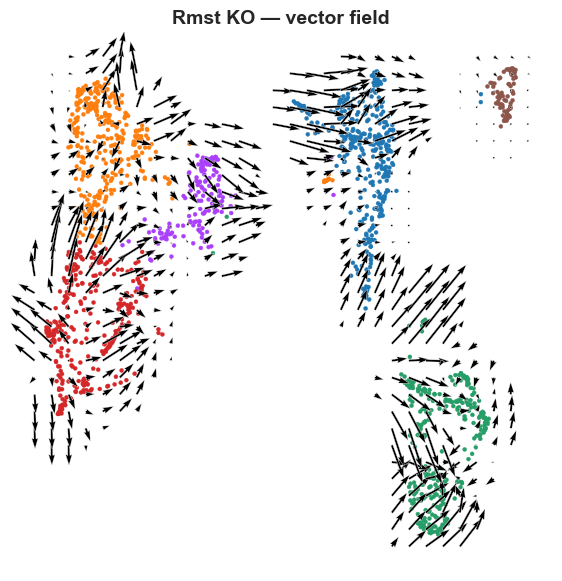

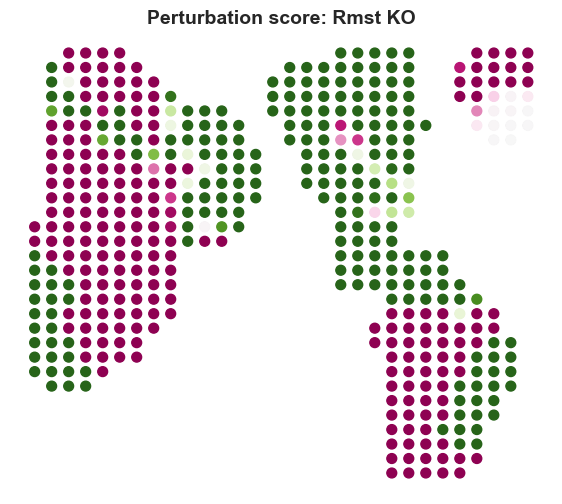

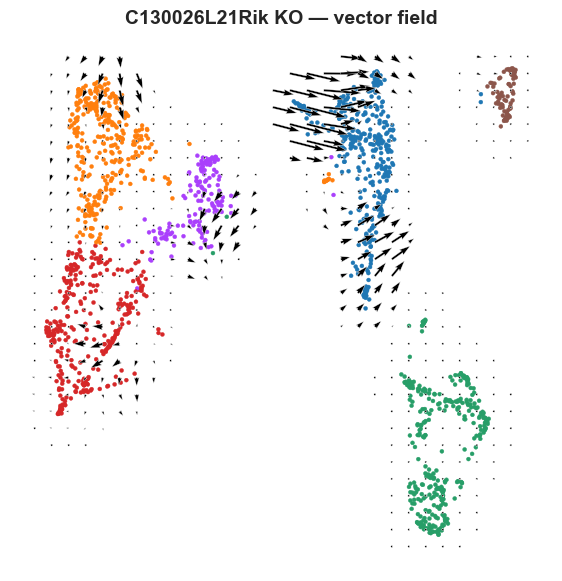

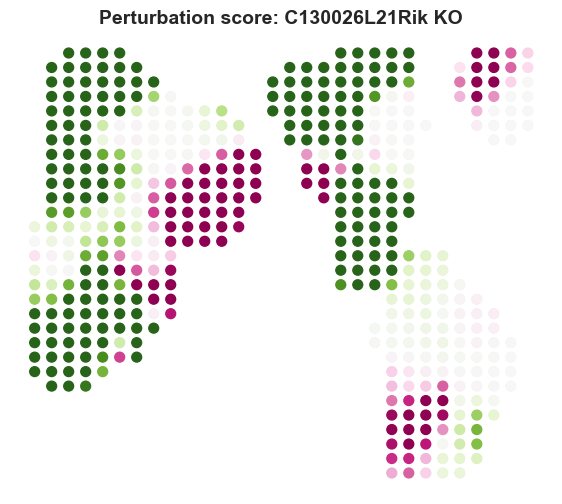

In [25]:
plt.close('all')

# ===============
#   PARAMETERS
# ===============
PSEUDOTIME_KEY = "Pseudotime"
N_GRID = 30
N_NEIGHBORS = 40
MIN_MASS = 0.35   # Adjust according to the values obtained with oracle.suggest_mass_thresholds()
SCALE=10

gradient = Gradient_calculator(oracle_object=oracle, pseudotime_key=PSEUDOTIME_KEY)
gradient.calculate_p_mass(smooth=0.8, n_grid=N_GRID, n_neighbors=N_NEIGHBORS)
gradient.calculate_mass_filter(min_mass=MIN_MASS, plot=False)
gradient.transfer_data_into_grid(args={"method": "polynomial", "n_poly": 3}, plot=False)
gradient.calculate_gradient()


def simulate_and_plot_ko(oracle, gene_name, gradient, cluster_col='leiden_annotated',
                          n_propagation=3, n_neighbors=N_NEIGHBORS, sampled_fraction=0.5,
                          sigma_corr=0.05, min_mass=MIN_MASS, n_grid=N_GRID,
                          scale_grid=SCALE, vm=0.02, save_prefix=None):

    # Simulate the KO and calculate the embedding shift
    oracle.simulate_shift(perturb_condition={gene_name: 0.0}, n_propagation=n_propagation)
    oracle.estimate_transition_prob(
        n_neighbors=n_neighbors,
        knn_random=True,
        sampled_fraction=sampled_fraction
    )
    oracle.calculate_embedding_shift(sigma_corr=sigma_corr)

    # Calculate the mass distribution using the same parameters as `gradient`
    oracle.calculate_p_mass(
        smooth=0.8,
        n_grid=n_grid,
        n_neighbors=n_neighbors,
        n_jobs=-1
    )
    oracle.calculate_mass_filter(min_mass=min_mass, plot=False)

    # Vector field on the grid
    fig1, ax1 = plt.subplots(figsize=(7, 7))
    oracle.plot_cluster_whole(ax=ax1, s=8)
    oracle.plot_simulation_flow_on_grid(
        scale=scale_grid,
        ax=ax1,
        show_background=False
    )
    ax1.set_title(
        f'{gene_name} KO — vector field',
        fontsize=14,
        fontweight='bold'
    )

    if save_prefix:
        fig1.savefig(
            f"{save_prefix}_vector_field.png",
            dpi=150,
            bbox_inches='tight'
        )

    plt.show()

    # Calculate and plot the perturbation score
    dev = Oracle_development_module()
    dev.load_differentiation_reference_data(gradient_object=gradient)
    dev.load_perturb_simulation_data(oracle_object=oracle)
    dev.calculate_inner_product()
    dev.calculate_digitized_ip(n_bins=10)

    fig2, ax2 = plt.subplots(figsize=(7, 6))
    dev.plot_inner_product_on_grid(vm=vm, s=50, ax=ax2)
    ax2.set_title(
        f'Perturbation score: {gene_name} KO',
        fontsize=14,
        fontweight='bold'
    )

    if save_prefix:
        fig2.savefig(
            f"{save_prefix}_perturbation_score.png",
            dpi=150,
            bbox_inches='tight'
        )

    plt.show()

    return fig1, fig2, dev

# --- Run for both lncRNAs ---
fig1_r, fig2_r, dev_rmst1 = simulate_and_plot_ko(oracle, "Rmst", gradient, save_prefix="../Plots/Simulations/KO_RMST1")
fig1_c, fig2_c, dev_c13   = simulate_and_plot_ko(oracle, "C130026L21Rik", gradient, save_prefix="../Plots/Simulations/KO_C13")

Inspect min mass values:

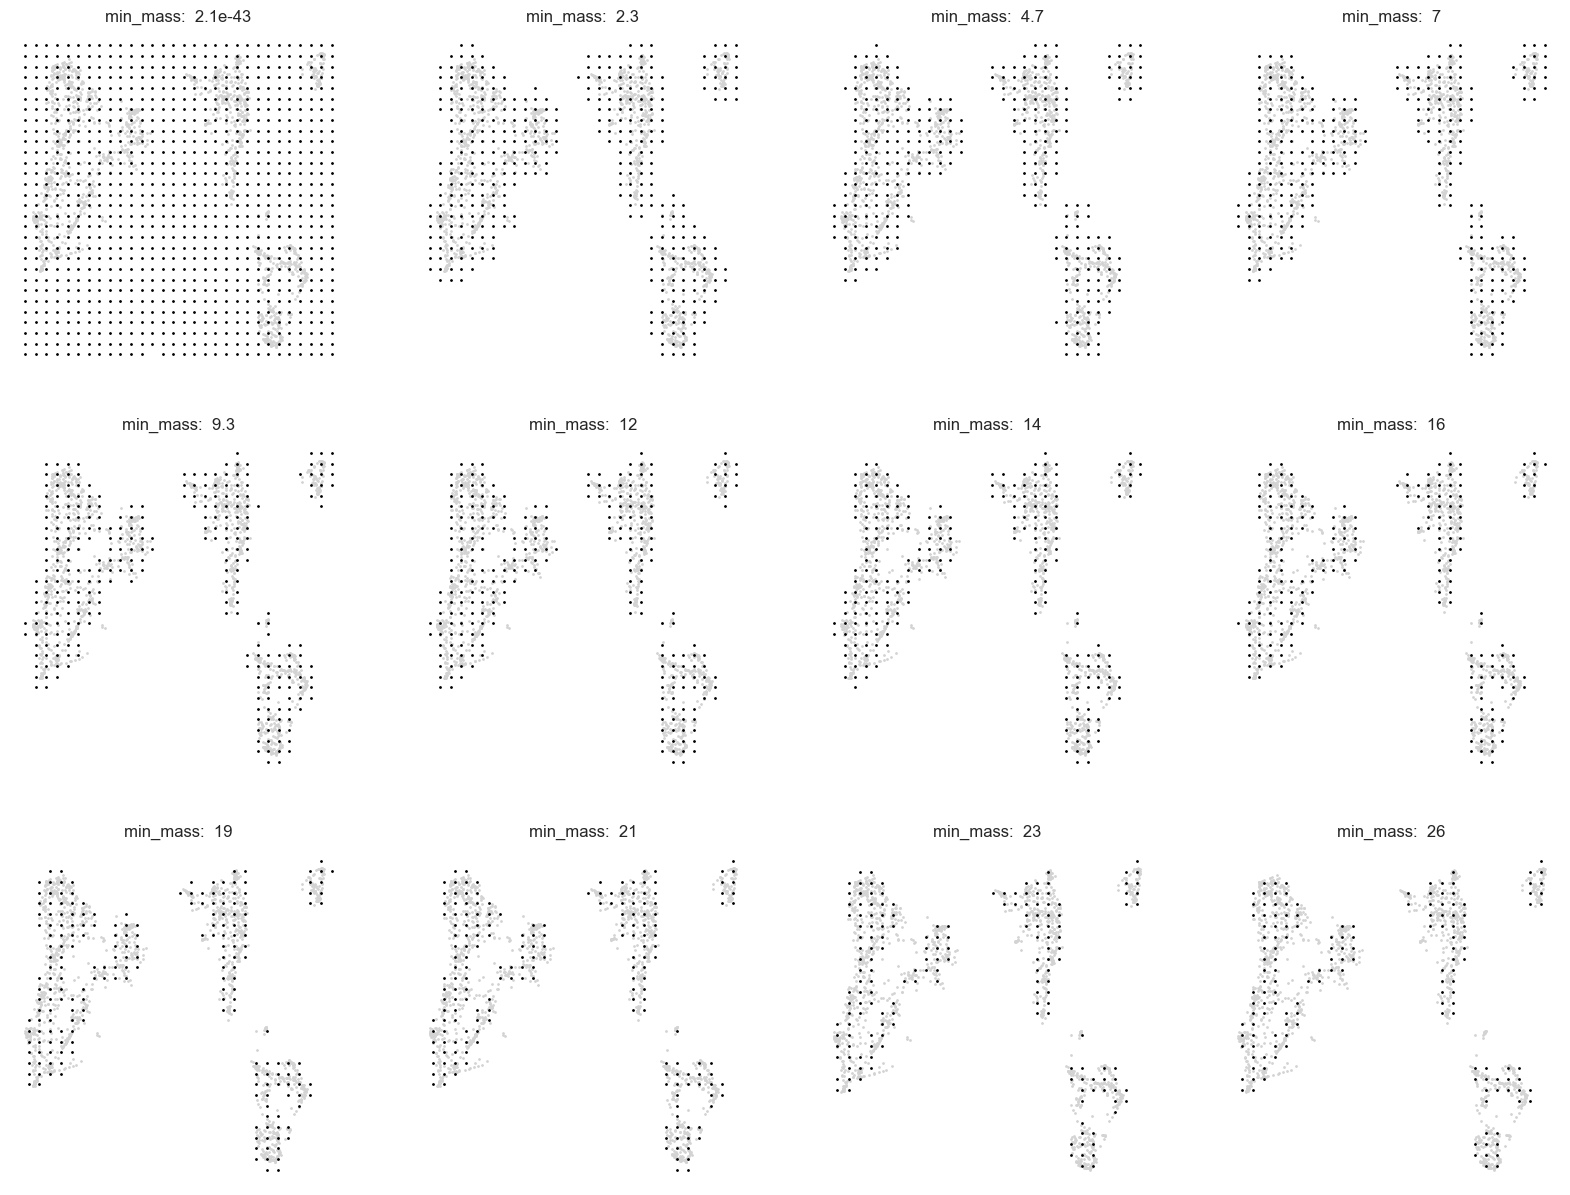

In [26]:
%matplotlib inline

oracle.suggest_mass_thresholds()

plt.show()